## __HYDROGEN MOLECULE__ ##

    Molekul hidrogen terdiri dari 2 atom yang saling berikatan, dan panjang ikatan ini tidak selalu tetap. Ketika jarak antar atom berubah, energi sistem juga akan berubah

__Tujuan utamanya__ menemukan energi dasar untuk setiap variasi jarak tersebut    

In [1]:
#import libraries
import numpy as np
from scipy.sparse import linalg

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

### __1. INISIALISASI__ ###

In [12]:
#membuat list untuk 17 panjang ikatan untuk moelkul hidrogen
bond_lengths = np.array([1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])/2

#menghitung rata-rata energi ground state dari paper Kolos et. al
enery_Kolos_upper = np.array([-1.12453881, -1.16493435, - 1.17234623, -1.17445199, -1.17447477, -1.17447498, -1.17446041 , -1.17285408, -1.16858212, -1.15506752, -1.13813155, -1.12013035, -1.10242011, -1.08578740, -1.07067758, -1.05731738, -1.04578647])
enery_Kolos_lower = np.array([-1.12453864, -1.16493411, -1.17234596, -1.17445199, -1.17447477, -1.17447466, -1.17446041 , -1.17285370, -1.16858164, -1.15506694, - 1.13813078, -1.12012903, -1.10241799, -1.08578400, -1.07067254, -1.05730948, -1.04577476])
enery_Kolos_mean = enery_Kolos_upper + enery_Kolos_lower
enery_Kolos_mean = enery_Kolos_mean/2

#membuat array kosong untuk menyimpan energi ground state hasil simulasi pada panjang ikatan yg berbeda
energy = []

### __2. SIMULATE THE GROUND STATE ENERGY OF THE HYDROGEN MOLECULE AT EACH BOND LENGTH__ ##

In [28]:
for bond_length in bond_lengths:
    #mengatur paramater molecul
    geometry = [('H', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, bond_length))]
    basis = 'sto-3g'
    multiplicity = 1
    charge = 0

    #menampilkan struktur elektronik molekul hidrogen dan obtain Hamiltonian as an InteractionOperator
    hamiltonian = ofpyscf.generate_molecular_hamiltonian(geometry, basis, multiplicity, charge)

    #convert to fermionic operator
    hamiltonian_ferm_op = of.get_fermion_operator(hamiltonian)

    #memetakan ke qubito dengan Jordan-Wigner transformation
    hamiltonian_bk = of.bravyi_kitaev(hamiltonian_ferm_op)

    #convert to scipy sparse matrix
    hamiltonian_bk_sparse = of.get_sparse_operator(hamiltonian_bk)

    #menghitung energi ground state dengan sparse eigensolver
    eigs, _ = linalg.eigsh(hamiltonian_bk_sparse, k=1, which='SA')
    ground_energy = eigs[0]

    #menyimpan energi ground state hasil simulasi di array kosong sebelumnya
    if bond_length == bond_lengths[0]:
       #print(f"Ground state energy for bond length {bond_length*2:.2f} Å: {ground_energy:.6f} Hartree (Kolos: {enery_Kolos_mean[0]:.6f} Hartree)")
        energy = np.array([ground_energy])
    else:
        energy = np.append(energy, ground_energy)
       #print(f"Ground state energy for bond length {bond_length*2:.2f}")

### __3. ANALISIS KUANTITATIF__ ###

In [29]:
#menghitung selisih antara energi simulasi dengan energi referensi (paper kolos et. al) dengan menghitung rata-rata dari selisih absolutnya
abs_diff = np.average(np.abs(energy - enery_Kolos_mean))
print("The absolute error between the two ground energy " 
      "dataset is {0:0.8f} Hartrees.\n".format(abs_diff))

#membandingkan energi hasil simulasi dengan energi referensi (paper kolos et. al) dengan menghitung rata-rata dari selisih absolutnya
rel_diff = np.average(np.abs(np.divide((energy - enery_Kolos_mean), 
                                       enery_Kolos_mean)))
print("The absolute relative error between the two ground "
	  "energy dataset is {0:0.2f}%.\n".format(rel_diff*100))

#panjang ikatan di mana energi ground state mencapai nilai minimum dalam simulasi ini
bond_lengths_min = bond_lengths[np.argmin(energy)]
print("The bond length corresponding to the lowest ground state "
	  "enery in this study is {0:0.3f} angstrom \n".format(bond_lengths_min))

#energi minimum yang diperoleh dari simulasi
print("The minimum ground state energy in this study is "
	  "{0:0.8f} Hartrees.\n".format(np.amin(energy)))

#panjang ikatan di mana energi ground state mencapai nilai minimum dalam paper kolos et.al
bond_lengths_min_Kolos = bond_lengths[np.argmin(enery_Kolos_mean)]
print("The bond length corresponding to the lowest ground state "
	  "enery in Kolos et al. study is {0:0.3f} angstrom \n".format(bond_lengths_min_Kolos))

#energi minimum yang diperoleh dari paper kolos et.al
print("The minimum ground state energy in Kolos et al. study is "
	  "{0:0.8f} Hartrees.\n".format(np.amin(enery_Kolos_mean)))

The absolute error between the two ground energy dataset is 0.04524362 Hartrees.

The absolute relative error between the two ground energy dataset is 4.02%.

The bond length corresponding to the lowest ground state enery in this study is 0.750 angstrom 

The minimum ground state energy in this study is -1.13711707 Hartrees.

The bond length corresponding to the lowest ground state enery in Kolos et al. study is 0.701 angstrom 

The minimum ground state energy in Kolos et al. study is -1.17447482 Hartrees.



## __4. PLOT ENERGI TERENDAH DARI MOELKUL HIDROGEN__ ##

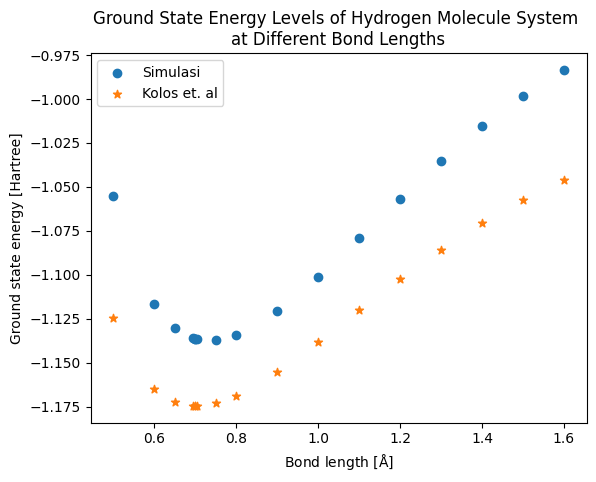

In [30]:
#plot kurva energy dari hasil simulasi
plt.scatter(bond_lengths, energy, marker= "o", label = "Simulasi")

#plot kurva energy dari paper kolos et. al
plt.scatter(bond_lengths, enery_Kolos_mean, marker= "*", label = "Kolos et. al")

plt.xlabel('Bond length [$\mathrm{\AA}$]')
plt.ylabel('Ground state energy [Hartree]')
plt.title('Ground State Energy Levels of Hydrogen Molecule System \nat Different Bond Lengths')
plt.legend()
plt.show()